In [2]:
# Libraries, modules
import soundfile as sf
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import hann
import matplotlib.pyplot as plt
import cv2
from skimage.feature import peak_local_max

rec_filename = "tmp_segments/000_segment.flac"

## Read full audio recording
data, fs = sf.read(rec_filename)

## Determine chunk number
filename = rec_filename.split("/")[-1] # Split the string by "/" to isolate the filename
chunk_no = int(filename.split("_")[0]) # Split the filename by "_", the number is the first part before "_segment"
print("Segment number: " + str(chunk_no))

Segment number: 0


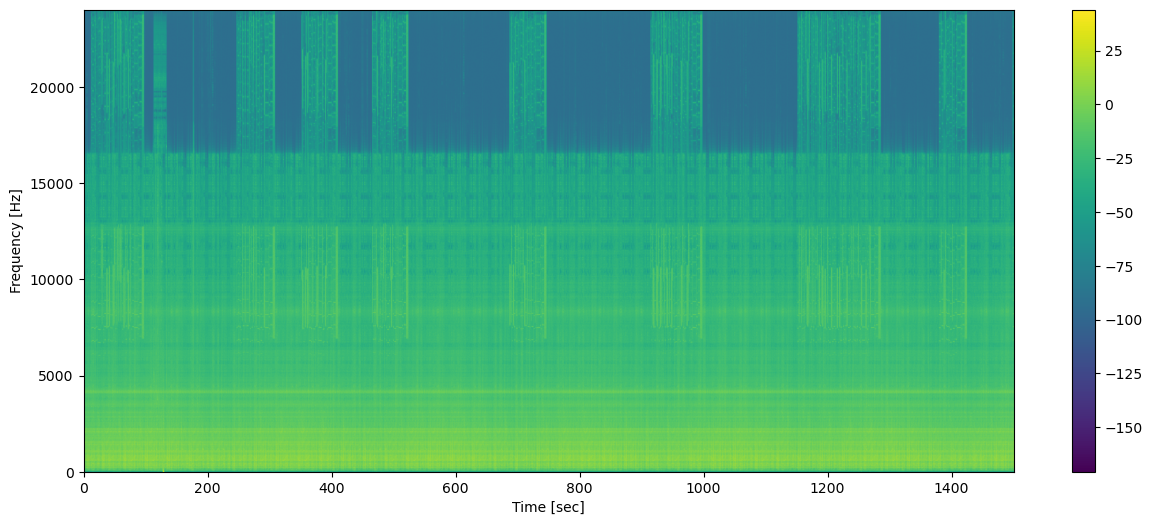

In [3]:
## Generate Spectrogram (2D FFT)
win_size = 4096 # 4096 seems to work better than 2048
win = hann(win_size) # Hann window
SFT = ShortTimeFFT(win, hop=win_size//2, fs=fs) # 50% overlap with hop=win_size/2
Sx2 = SFT.spectrogram(data)  # Spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with minimum non-zero value
Sx2_dB = 10*np.log10(Sx2) # Spectrogram in dB
t_min, t_max, f_min, f_max = SFT.extent(len(data), center_bins=True) # Frequency and time boundaries
f_bins, t_bins = Sx2.shape # Number of frequency and time bins

# Plot spectrogram (in dB)
plt.figure(figsize=(15,6))
plt.imshow(Sx2_dB, origin='lower', aspect='auto', extent=SFT.extent(len(data)))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [4]:
# Spectrogram bandpass filter
def spec_bandpass(spec, f_max, f_bins, f_low, f_high):
    f_bl = int(f_low/f_max*f_bins) # Low frequency bin
    f_bh = int(f_high/f_max*f_bins) # High frequency bin
    return spec[f_bl:f_bh,:]

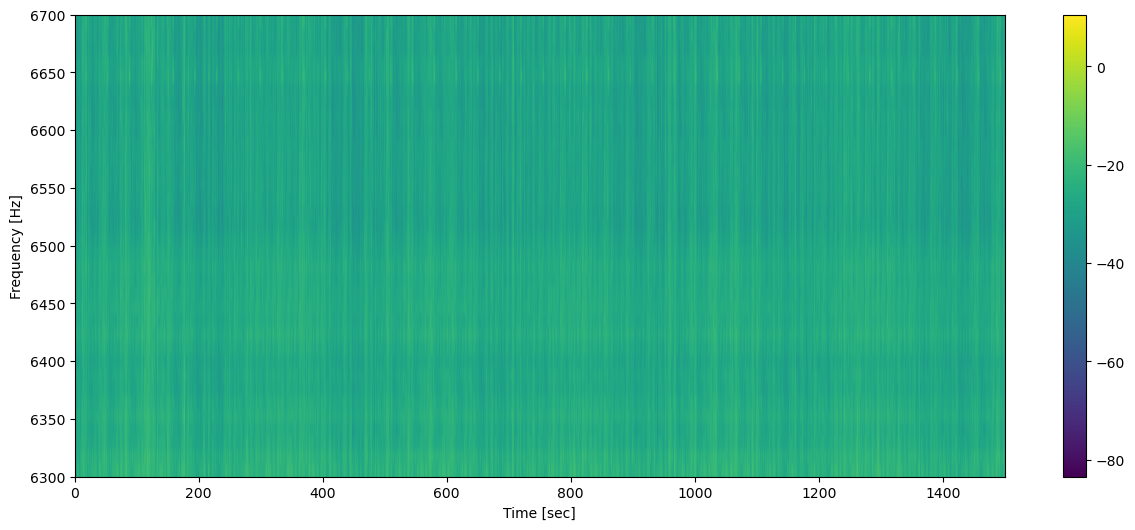

mean -27.243720064566908
std 7.091154527502911


In [5]:
## Measure background noise level
noise = spec_bandpass(Sx2_dB, f_max, f_bins, 6300, 6700)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(noise, origin='lower', aspect='auto', extent=[t_min, t_max, 6300, 6700])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

noise_mean = np.mean(noise)
noise_std = np.std(noise)
print("mean " + str(noise_mean))
print("std " + str(noise_std))

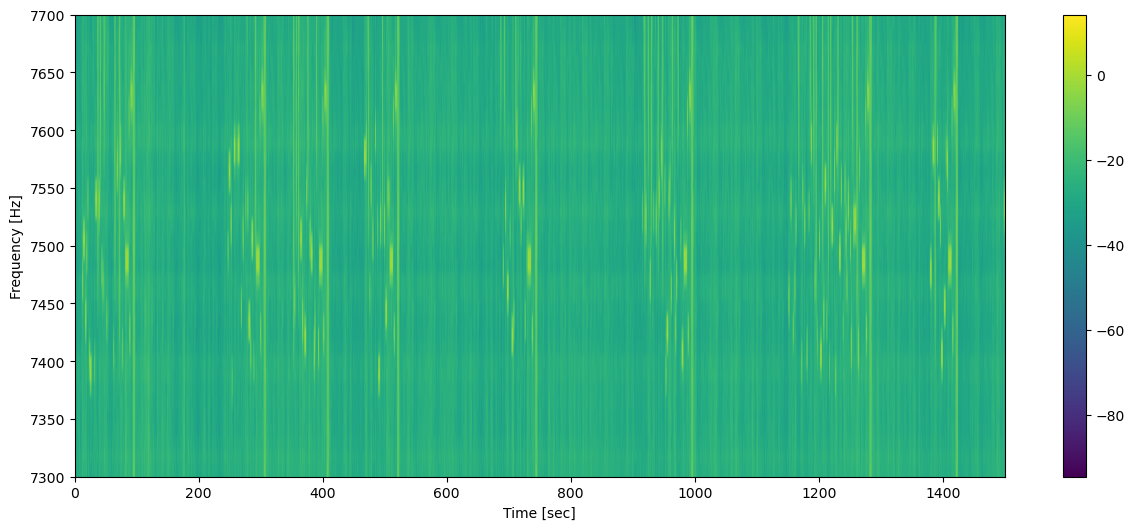

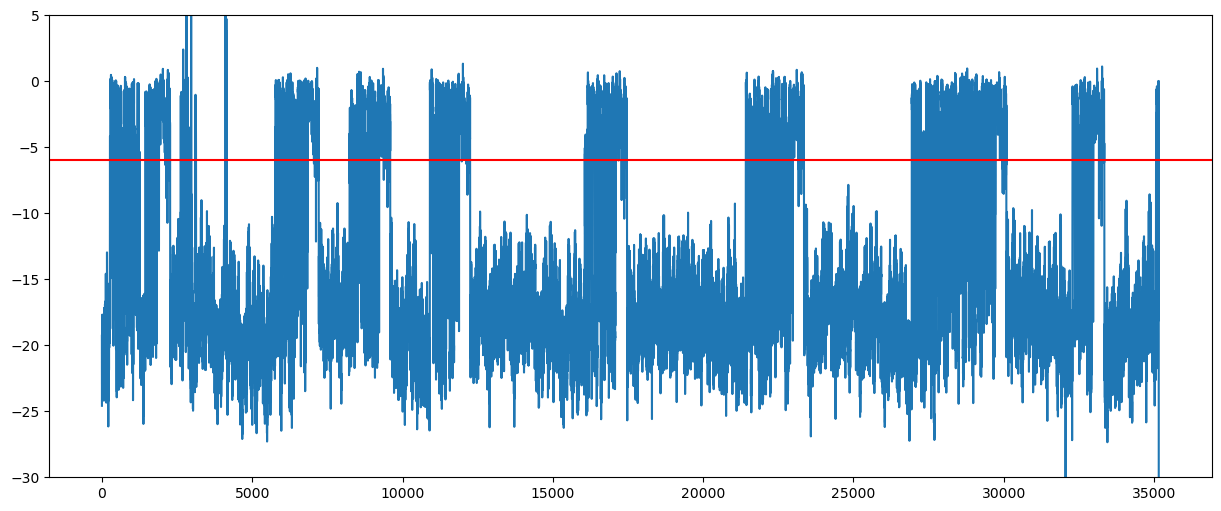

In [6]:
## Measure signal level at low frequencies
sig_low = spec_bandpass(Sx2_dB, f_max, f_bins, 7300, 7700)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(sig_low, origin='lower', aspect='auto', extent=[t_min, t_max, 7300, 7700])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

sig_level_l = np.max(sig_low, axis=0)

plt.figure(figsize=(15,6))
plt.plot(sig_level_l)
plt.axhline(y = noise_mean + noise_std*3, color = 'r', linestyle = '-')
plt.ylim(-30, 5)

plt.show()

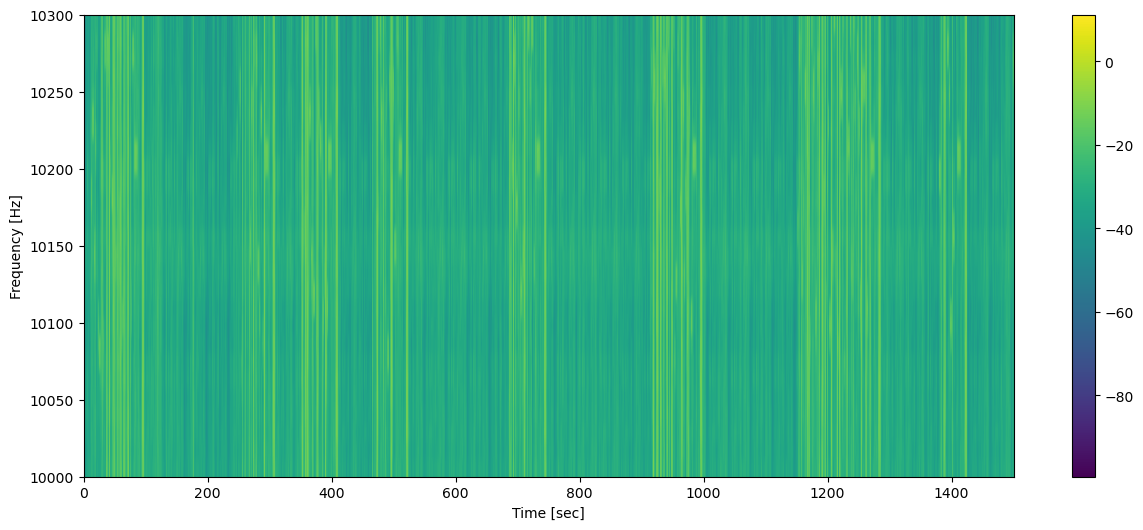

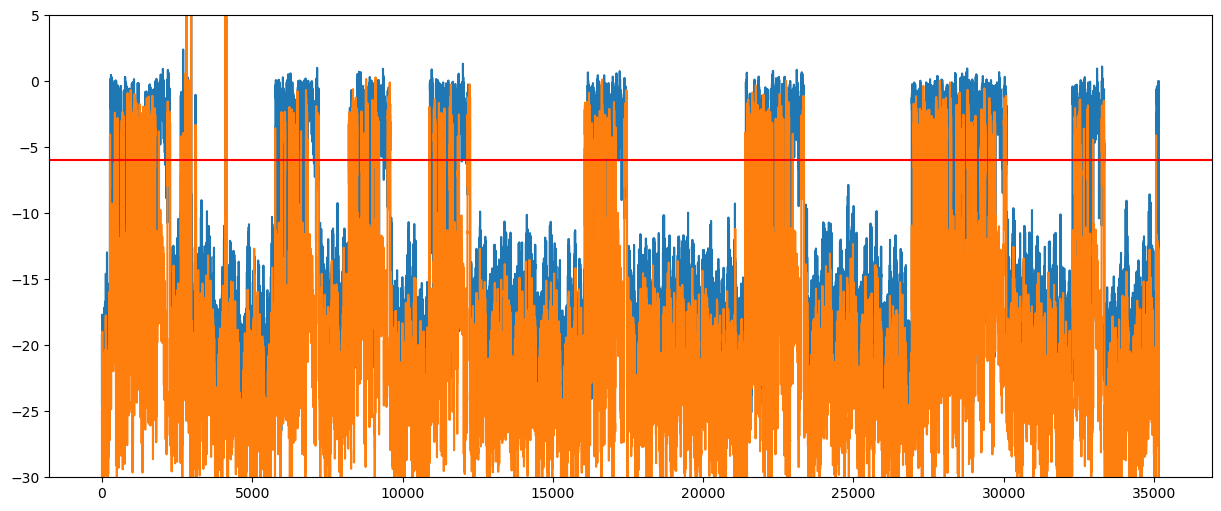

In [8]:
## Measure signal level at high frequencies
sig_high = spec_bandpass(Sx2_dB, f_max, f_bins, 10000, 10300)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(sig_high, origin='lower', aspect='auto', extent=[t_min, t_max, 10000, 10300])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

sig_level_h = np.max(sig_high, axis=0)

plt.figure(figsize=(15,6))
plt.plot(sig_level_l)
plt.plot(sig_level_h)
plt.axhline(y = noise_mean + noise_std*3, color = 'r', linestyle = '-')
plt.ylim(-30, 5)
plt.show()

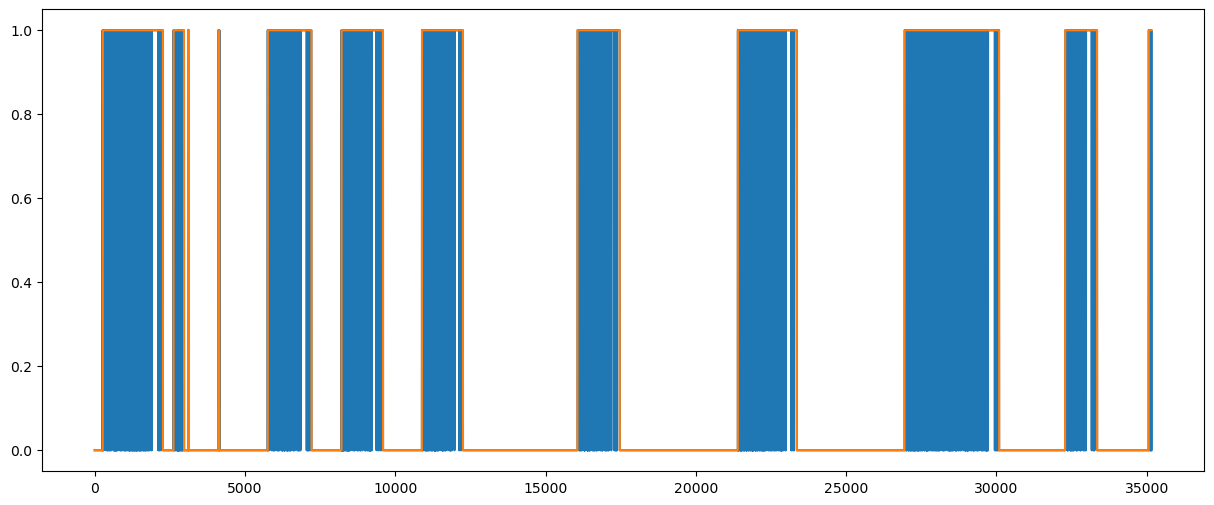

In [9]:
## Create "detection" array
threshold = noise_mean + noise_std*3 # Threshold level to detect a signal
above_threshold = ((sig_level_l > threshold) | (sig_level_h > threshold)).astype(int) # Array of detections (1) and non-detections (0)

# Function to fill gaps in a sequence of signals
def fill_gaps(arr, n):
    result = arr.copy()
    i = 0
    while i < len(result):
        if result[i] == 0: # Found the start of a sequence of 0s            
            start = i
            while i < len(result) and result[i] == 0: # Find the end of this sequence
                i += 1
            end = i            
            if end - start < n: # If the length of the sequence is shorter than n, replace with 1s
                for j in range(start, end):
                    result[j] = 1
        else:
            i += 1    
    return result

max_zeros = int(fs/win_size*2*5) # 5 seconds, very conservative, I found that 1 second is sufficient 
sig_detected = fill_gaps(above_threshold, max_zeros)
plt.figure(figsize=(15,6))
plt.plot(above_threshold)
plt.plot(sig_detected)
plt.show()

In [10]:
## Detect signal sequences

def detect_sequences(bin_list):
    sequences = []
    start_idx = None    
    for i, num in enumerate(bin_list): # Go through detection array
        if num == 1:
            if start_idx is None:  # Beginning of a new sequence of 1s
                start_idx = i
        elif num == 0 and start_idx is not None:  # End the sequence when we hit a 0 after detecting 1s
            sequences.append((start_idx, i - 1))  # End of sequence
            start_idx = None    
    if start_idx is not None:     # If we end with a sequence of 1s and it's still open, close it
        sequences.append((start_idx, len(bin_list) - 1))    
    return sequences

sequences = detect_sequences(sig_detected)

for seq in sequences:
    print(seq)

(267, 2267)
(2623, 2970)
(3113, 3130)
(4110, 4146)
(5759, 7210)
(8211, 9589)
(10886, 12248)
(16061, 17464)
(21396, 23354)
(26940, 30086)
(32283, 33345)
(35064, 35157)


In [11]:
## Filter out noise
# Typically, this is due to in-game sounds

min_samples = int(fs/win_size*26.6) # The minimum duration of a sequence of signals is ~26.6 seconds
print(min_samples)

# Filter out sequences where the difference between end and start is less than n
def delete_short_sequences(sequences, n):    
    return [seq for seq in sequences if (seq[1] - seq[0] + 1) >= n]

sequences = delete_short_sequences(sequences, min_samples)
    
for seq in sequences:
    print(seq)

311
(267, 2267)
(2623, 2970)
(5759, 7210)
(8211, 9589)
(10886, 12248)
(16061, 17464)
(21396, 23354)
(26940, 30086)
(32283, 33345)


In [12]:
## Filter out sequences at the beginning and end of recording
# They are truncated and thus incomplete

# Filter out sequences that are at the beginning (start_idx == 0) or at the end (end_idx == length - 1)
def delete_edge_sequences(sequences):
    length = len(sig_detected)
    return [seq for seq in sequences if seq[0] != 0 and seq[1] != length - 1]

sequences = delete_edge_sequences(sequences)
    
for seq in sequences:
    print(seq)

(5566, 6461)
(9303, 10514)
(13665, 15572)
(17028, 17928)
(20122, 21016)
(22575, 23549)
(24791, 25808)
(27156, 28033)
(31749, 33022)


In [14]:
## Turn sequences expressed as sample numbers into time in seconds

# Sort by start sample
sequences = sorted(sequences, key=lambda sequences: sequences[0])

# Delete duplicate detections

# Convert to time in seconds
timing = np.array(sequences)/(fs/(win_size/2))

# Add shift due to segmentation
timing = timing + chunk_no*1200

# Add 10 s of buffer before and after each segment for safety
timing[:, 0] = timing[:, 0] - 10
timing[:, 1] = timing[:, 1] + 10

# Round to 8th decimal digit, the mimimum time step at 48kHz is 0.00002083333...
timing = np.round(timing, 8)

print(timing)

[[8627.48266667 8685.66933333]
 [8786.928      8858.59733333]
 [8973.04       9074.40533333]
 [9116.528      9174.928     ]
 [9248.53866667 9306.68266667]
 [9353.2        9414.75733333]
 [9447.74933333 9511.14133333]
 [9548.656      9606.07466667]
 [9744.624      9818.93866667]]
